In [2]:
import pandas as pd
import numpy as np
import os

# Load activity labels
activity_labels = pd.read_csv(
    '../data/UCI HAR Dataset/activity_labels.txt', 
    sep=' ', header=None, names=['id', 'activity']
)
print(activity_labels)

# Load training data
X_train = pd.read_csv(
    '../data/UCI HAR Dataset/train/X_train.txt', 
    sep=r'\s+', header=None
)
y_train = pd.read_csv(
    '../data/UCI HAR Dataset/train/y_train.txt', 
    header=None, names=['activity_id']
)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"\nClass distribution:\n{y_train['activity_id'].value_counts().sort_index()}")

   id            activity
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING

Training data shape: (7352, 561)
Training labels shape: (7352, 1)

Class distribution:
activity_id
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


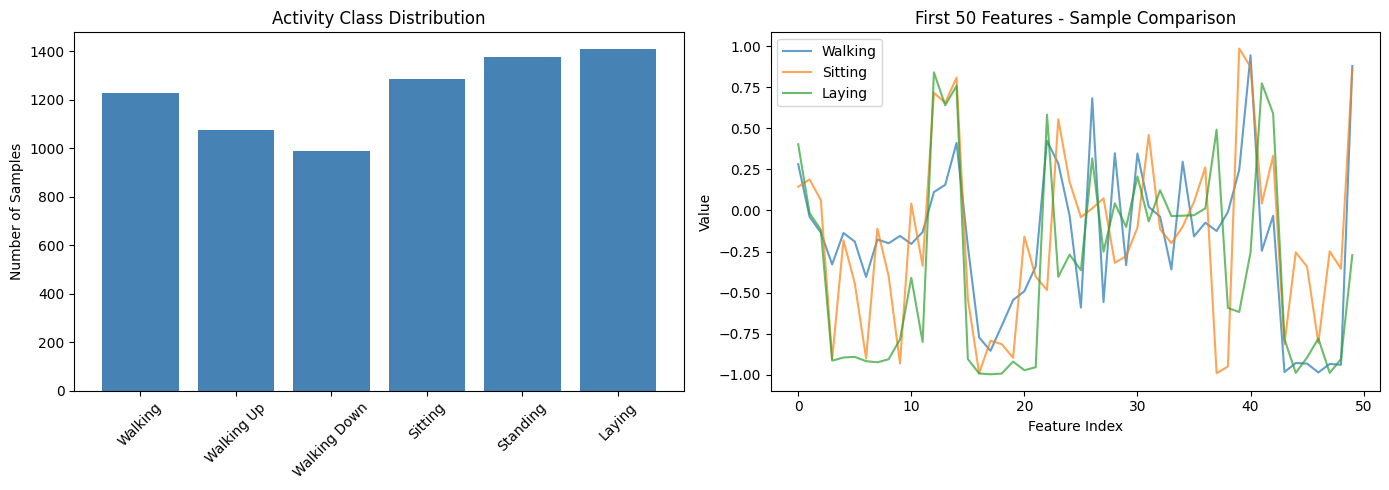

Plot saved to results/data_exploration.png


In [3]:
import matplotlib.pyplot as plt

# Activity name mapping
activities = {1: 'Walking', 2: 'Walking Up', 3: 'Walking Down', 
              4: 'Sitting', 5: 'Standing', 6: 'Laying'}

# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of class distribution
counts = y_train['activity_id'].value_counts().sort_index()
axes[0].bar([activities[i] for i in counts.index], counts.values, color='steelblue')
axes[0].set_title('Activity Class Distribution')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)

# Plot first 5 features for different activities
for act_id in [1, 4, 6]:  # Walking, Sitting, Laying
    mask = y_train['activity_id'] == act_id
    sample = X_train[mask].iloc[0, :50]  # first 50 features of first sample
    axes[1].plot(sample.values, label=activities[act_id], alpha=0.7)

axes[1].set_title('First 50 Features - Sample Comparison')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Value')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/data_exploration.png', dpi=150)
plt.show()
print("Plot saved to results/data_exploration.png")

In [4]:
def load_signals(subset, base_path='../data/UCI HAR Dataset'):
    signal_types = [
        'body_acc_x', 'body_acc_y', 'body_acc_z',
        'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
        'total_acc_x', 'total_acc_y', 'total_acc_z'
    ]
    signals = []
    for signal in signal_types:
        filepath = os.path.join(base_path, subset, 'Inertial Signals', f'{signal}_{subset}.txt')
        data = pd.read_csv(filepath, sep=r'\s+', header=None)
        signals.append(data.values)
    return np.stack(signals, axis=-1)

X_train_raw = load_signals('train')
X_test_raw = load_signals('test')

y_test = pd.read_csv(
    '../data/UCI HAR Dataset/test/y_test.txt',
    header=None, names=['activity_id']
)

print(f"Raw training data shape: {X_train_raw.shape}")
print(f"Raw test data shape: {X_test_raw.shape}")
print(f"Each sample: {X_train_raw.shape[1]} timesteps x {X_train_raw.shape[2]} sensor channels")

Raw training data shape: (7352, 128, 9)
Raw test data shape: (2947, 128, 9)
Each sample: 128 timesteps x 9 sensor channels
